# 1. Análisis del Impacto de Noticias y Opiniones en la Volatilidad de Memecoins mediante NLP

A continuación en este notebook se realizará un EDA de los diferentes ficheros a emplear durante el proyecto, también se analizará los sentimientos de uno de los datasets recogidos y por último se analizarán la relación entre las diferentes opiniones con la volatilidad de los memecoins.

# 2. EDA de Datos de Criptomonedas
 En este punto realizaremos un Análisis Exploratorio de Datos (EDA) utilizando dos conjuntos de datos relacionados con la volatilidad de criptomonedas.

 El primer conjunto contiene información sobre PEPE, DOGE y SHIBA durante 365 días, y el segundo conjunto sobre el precio diario en 365 días será analizado de manera similar.

 Utilizaremos bibliotecas como ggplot2, dplyr y otros para explorar y visualizar las métricas relacionadas con el rango de precios, cambio
 porcentual y volatilidad relativa.


## 2.1 EDA sobre fichero combined_volatility_365_days.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Cargar los datos
combined_volatility = pd.read_csv('combined_volatility_365_days.csv', sep=';', decimal=',')

# Verificar las primeras filas
print(combined_volatility.head())

         date      open      high       low     close         range  \
0  2024-05-09  0.000008  0.000008  0.000008  0.000008  5.800000e-07   
1  2024-05-13  0.000008  0.000009  0.000008  0.000009  1.010000e-06   
2  2024-05-17  0.000009  0.000012  0.000008  0.000010  3.180000e-06   
3  2024-05-21  0.000010  0.000011  0.000009  0.000011  2.290000e-06   
4  2024-05-25  0.000011  0.000015  0.000011  0.000014  4.370000e-06   

   pct_change  rel_volatility  coin  
0    0.756620        0.072956  pepe  
1    9.924623        0.119739  pepe  
2   14.595211        0.320565  pepe  
3   11.952191        0.226845  pepe  
4   25.198939        0.334226  pepe  


In [6]:
# Asegurarse de que la columna 'date' esté en formato datetime
combined_volatility['date'] = pd.to_datetime(combined_volatility['date'])

# Verificar los tipos de datos (opcional)
print(combined_volatility.dtypes)

# Obtener la lista de monedas únicas
coins = combined_volatility['coin'].unique()

# Generar resumen estadístico por cada coin
for coin in coins:
    print(f"\nResumen estadístico para {coin}:")
    print(combined_volatility[combined_volatility['coin'] == coin].describe())


date              datetime64[ns]
open                     float64
high                     float64
low                      float64
close                    float64
range                    float64
pct_change               float64
rel_volatility           float64
coin                      object
dtype: object

Resumen estadístico para pepe:
                      date       open       high        low      close  \
count                   92  92.000000  92.000000  92.000000  92.000000   
mean   2024-11-07 00:00:00   0.000012   0.000013   0.000010   0.000012   
min    2024-05-09 00:00:00   0.000007   0.000007   0.000005   0.000007   
25%    2024-08-08 00:00:00   0.000008   0.000009   0.000008   0.000008   
50%    2024-11-07 00:00:00   0.000010   0.000011   0.000009   0.000010   
75%    2025-02-06 00:00:00   0.000014   0.000015   0.000012   0.000014   
max    2025-05-08 00:00:00   0.000024   0.000028   0.000022   0.000024   
std                    NaN   0.000005   0.000005   0.000004   0.0

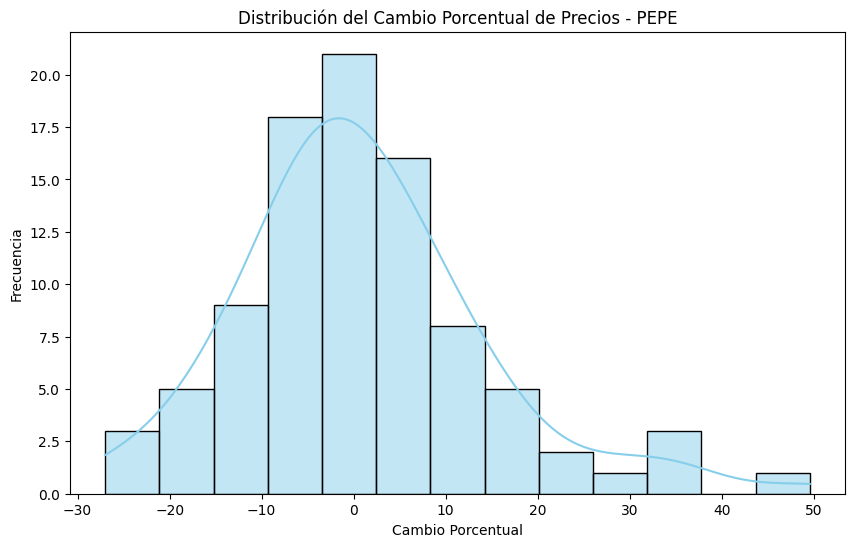

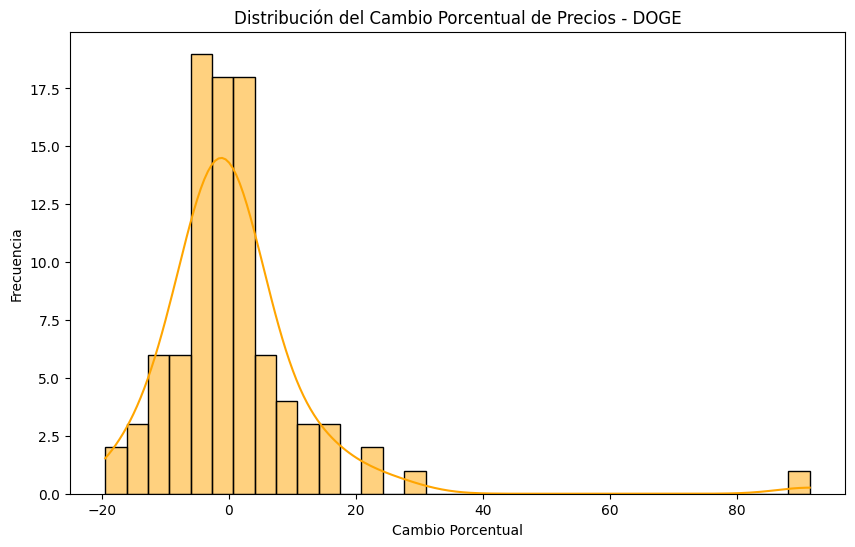

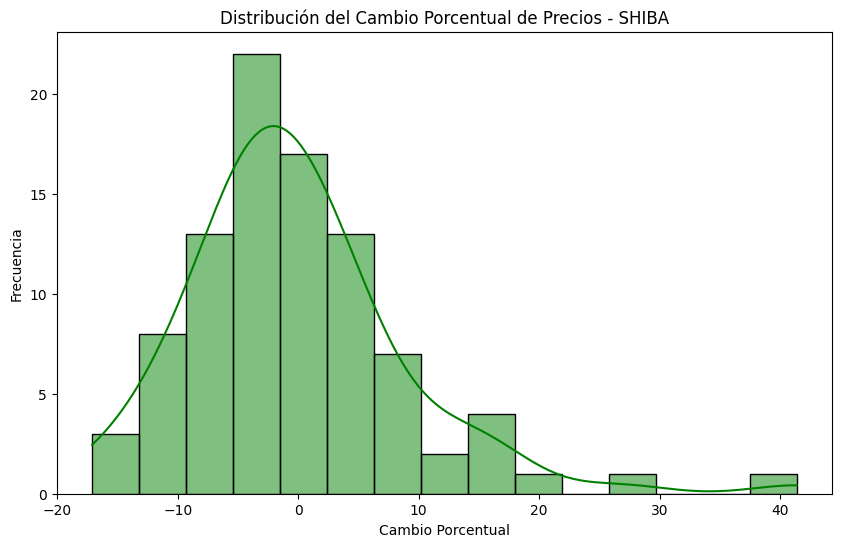

In [ ]:
# Filtrar los datos para cada criptomoneda y crear los histogramas por separado

# Histograma para PEPE
plt.figure(figsize=(10, 6))
sns.histplot(combined_volatility[combined_volatility['coin'] == 'pepe']['pct_change'], kde=True, color='skyblue')
plt.title('Distribución del Cambio Porcentual de Precios - PEPE')
plt.xlabel('Cambio Porcentual')
plt.ylabel('Frecuencia')
plt.show()

# Histograma para DOGE
plt.figure(figsize=(10, 6))
sns.histplot(combined_volatility[combined_volatility['coin'] == 'doge']['pct_change'], kde=True, color='orange')
plt.title('Distribución del Cambio Porcentual de Precios - DOGE')
plt.xlabel('Cambio Porcentual')
plt.ylabel('Frecuencia')
plt.show()

# Histograma para SHIBA
plt.figure(figsize=(10, 6))
sns.histplot(combined_volatility[combined_volatility['coin'] == 'shiba']['pct_change'], kde=True, color='green')
plt.title('Distribución del Cambio Porcentual de Precios - SHIBA')
plt.xlabel('Cambio Porcentual')
plt.ylabel('Frecuencia')
plt.show()

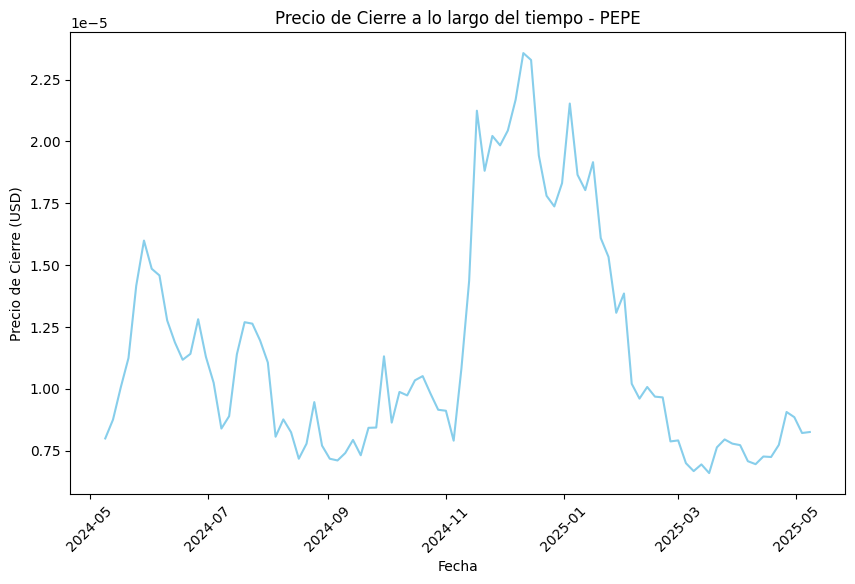

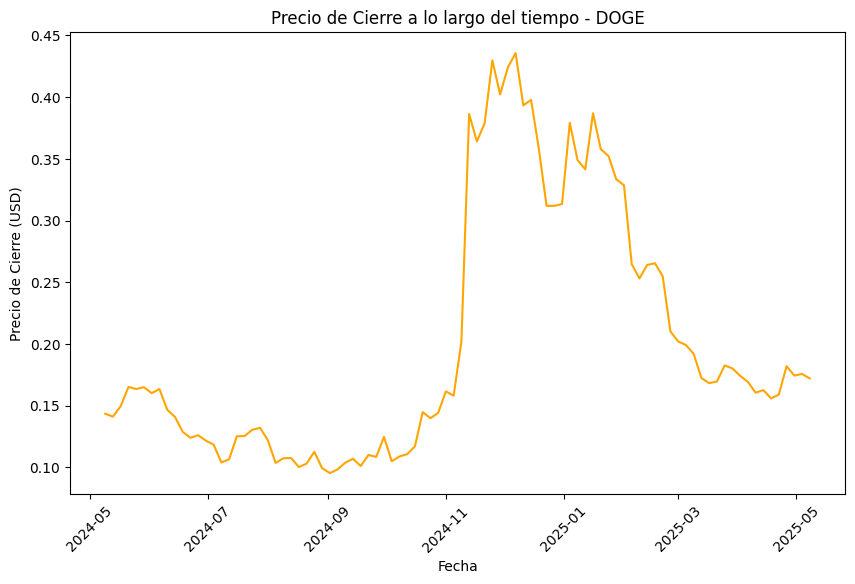

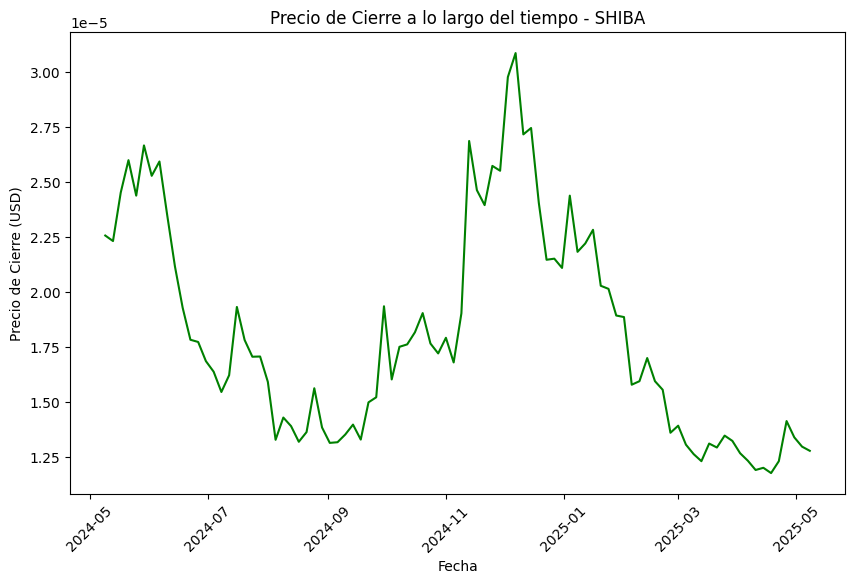

In [ ]:
# Gráfico de serie temporal para PEPE
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='close', data=combined_volatility[combined_volatility['coin'] == 'pepe'], color='skyblue')
plt.title('Precio de Cierre a lo largo del tiempo - PEPE')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

# Gráfico de serie temporal para DOGE
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='close', data=combined_volatility[combined_volatility['coin'] == 'doge'], color='orange')
plt.title('Precio de Cierre a lo largo del tiempo - DOGE')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

# Gráfico de serie temporal para SHIBA
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='close', data=combined_volatility[combined_volatility['coin'] == 'shiba'], color='green')
plt.title('Precio de Cierre a lo largo del tiempo - SHIBA')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()


## 2.2 EDA sobre fichero combined_prices_365_days.csv

In [7]:
# Cargar los datos
combined_prices = pd.read_csv('combined_prices_365_days.csv', sep=';', decimal=',')

# Verificar las primeras filas
print(combined_prices.head())

         date        timestamp                  price  coin
0  2024-05-09  1715212800000.0   7.98742699566289e-06  pepe
1  2024-05-10  1715299200000.0  8.549701409515095e-06  pepe
2  2024-05-11  1715385600000.0  8.415972348662765e-06  pepe
3  2024-05-12  1715472000000.0  8.475291260185867e-06  pepe
4  2024-05-13  1715558400000.0  8.754519453115519e-06  pepe


In [8]:
# Conversión de tipos de datos
combined_prices['date'] = pd.to_datetime(combined_prices['date'])
combined_prices['price'] = combined_prices['price'].astype(float)

# Redondear los precios (esto es útil para visualizar mejor, aunque no para análisis profundo)
combined_prices['price_rounded_no_exp'] = combined_prices['price'].apply(lambda x: round(x, 8))

# Verificar los tipos de datos después de la conversión
print(combined_prices.dtypes)

# Obtener lista de monedas
coins = combined_prices['coin'].unique()

# Resumen estadístico por moneda
for coin in coins:
    print(f"\nResumen estadístico de precios para {coin}:")
    print(combined_prices[combined_prices['coin'] == coin].describe())


date                    datetime64[ns]
timestamp                       object
price                          float64
coin                            object
price_rounded_no_exp           float64
dtype: object

Resumen estadístico de precios para pepe:
                      date       price  price_rounded_no_exp
count                  365  365.000000            365.000000
mean   2024-11-07 00:00:00    0.000012              0.000012
min    2024-05-09 00:00:00    0.000006              0.000006
25%    2024-08-08 00:00:00    0.000008              0.000008
50%    2024-11-07 00:00:00    0.000010              0.000010
75%    2025-02-06 00:00:00    0.000014              0.000014
max    2025-05-08 00:00:00    0.000026              0.000026
std                    NaN    0.000005              0.000005

Resumen estadístico de precios para doge:
                      date       price  price_rounded_no_exp
count                  365  365.000000            365.000000
mean   2024-11-07 00:00:00    0.20

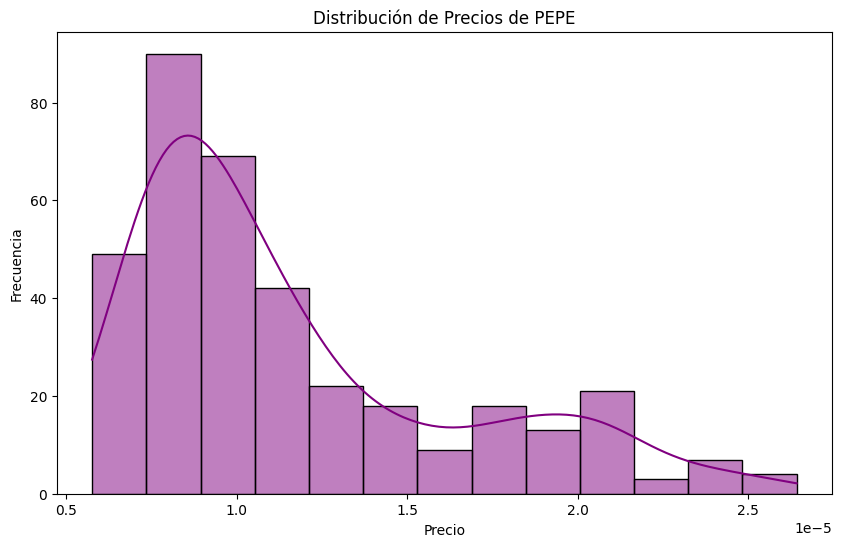

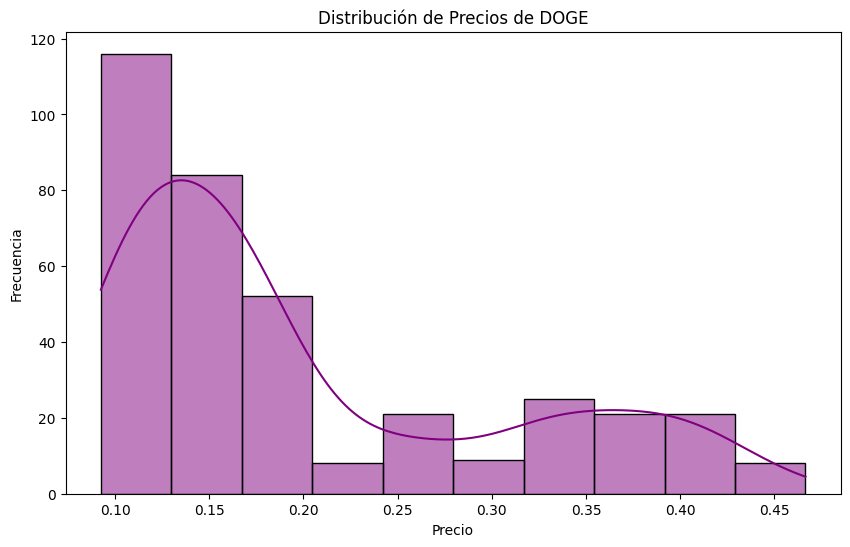

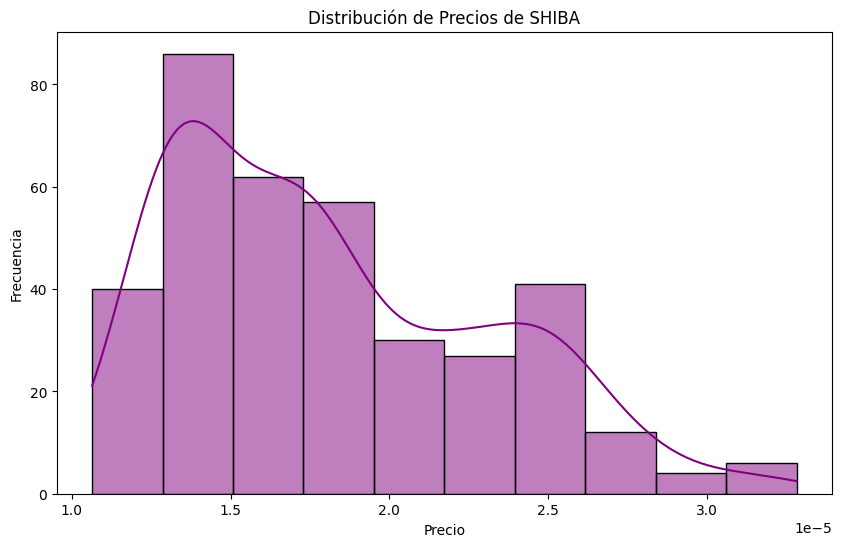

In [ ]:
# Histograma de precios para cada criptomoneda
for coin in combined_prices['coin'].unique():
    plt.figure(figsize=(10, 6))
    sns.histplot(combined_prices[combined_prices['coin'] == coin]['price_rounded_no_exp'], kde=True, color='purple')
    plt.title(f'Distribución de Precios de {coin.upper()}')
    plt.xlabel('Precio')
    plt.ylabel('Frecuencia')
    plt.show()


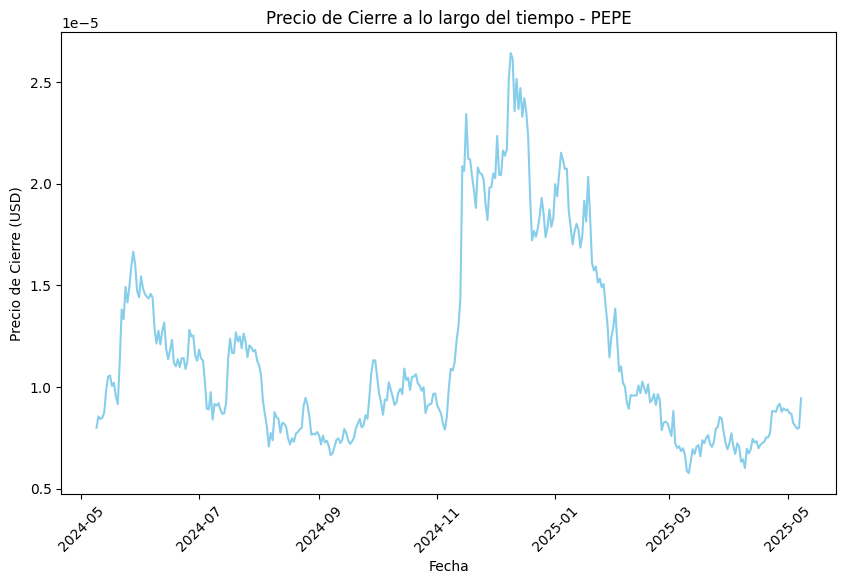

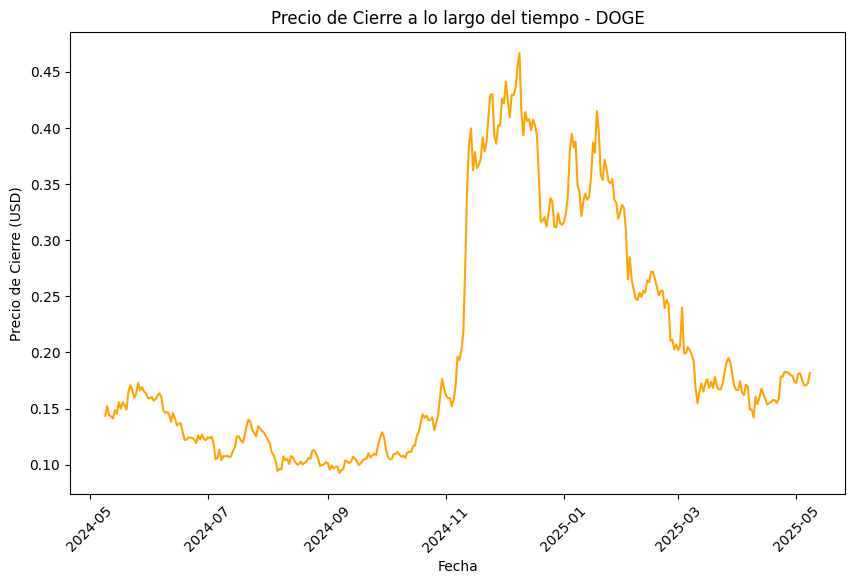

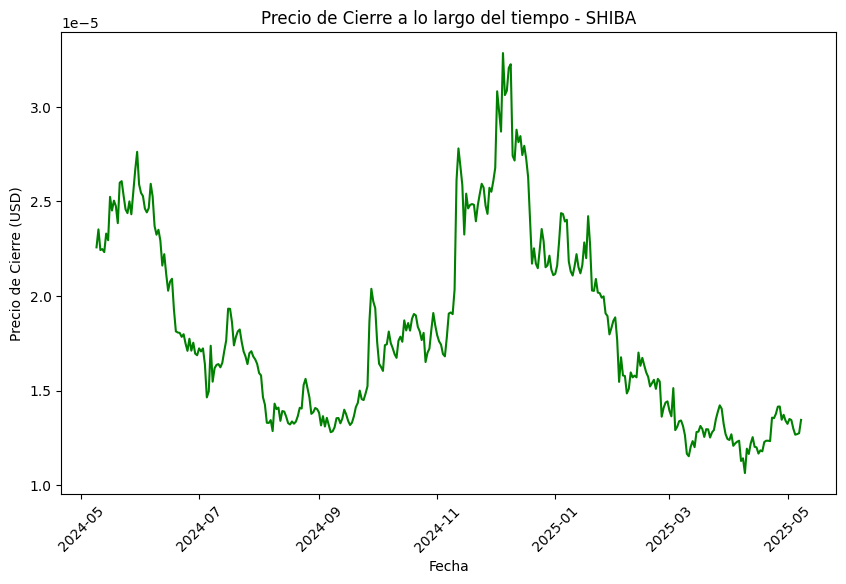

In [ ]:
# Gráfico de serie temporal para PEPE
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='price_rounded_no_exp', data=combined_prices[combined_prices['coin'] == 'pepe'], color='skyblue')
plt.title('Precio de Cierre a lo largo del tiempo - PEPE')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

# Gráfico de serie temporal para DOGE
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='price_rounded_no_exp', data=combined_prices[combined_prices['coin'] == 'doge'], color='orange')
plt.title('Precio de Cierre a lo largo del tiempo - DOGE')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

# Gráfico de serie temporal para SHIBA
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='price_rounded_no_exp', data=combined_prices[combined_prices['coin'] == 'shiba'], color='green')
plt.title('Precio de Cierre a lo largo del tiempo - SHIBA')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()